In [4]:
import os

# Change this to where your dataset folder is
BASE = r"C:\Users\patta\Videos\Railway Track Surface Faults Dataset"

# Print everything inside
for root, dirs, files in os.walk(BASE):
    level = root.replace(BASE, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for d in dirs:
            print(f"  {indent}{d}/")
    break

Railway Track Surface Faults Dataset/
  Cracks/
  Flakings/
  Railway Track Surface Faults Dataset/
  Squats/


Splitting dataset into train / valid / test ...
Classes found: ['Cracks', 'Flakings', 'Squats']
Cracks -> Train: 1399 | Valid: 300 | Test: 300
Flakings -> Train: 1400 | Valid: 300 | Test: 300
Squats -> Train: 1400 | Valid: 300 | Test: 300
Dataset Split Done!

Found 4199 images belonging to 3 classes.
Found 900 images belonging to 3 classes.
Found 900 images belonging to 3 classes.
Class Indices: {'Cracks': 0, 'Flakings': 1, 'Squats': 2}
71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 30s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 380, 380, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling (Rescaling)         │ (None, 380, 380, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization (Normalization) │ (None, 380, 380, 3)       │               7 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_1 (Rescaling)       │ (None, 380, 380, 3)       │               0 │ normalization[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 381, 381, 3)       │               0 │ rescaling_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 190, 190, 48)      │           1,296 │ stem_conv_pad[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 190, 190, 48)      │             192 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 190, 190, 48)      │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_dwconv                │ (None, 190, 190, 48)      │             432 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_bn                    │ (None, 190, 190, 48)      │             192 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_activation            │ (None, 190, 190, 48)      │               0 │ block1a_bn[0][0]           │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_squeeze            │ (None, 48)                │               0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reshape (Reshape)  │ (None, 1, 1, 48)          │               0 │ block1a_se_squeeze[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reduce (Conv2D)    │ (None, 1, 1, 12)          │             588 │ block1a_se_reshape[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_expand (Conv2D)    │ (None, 1, 1, 48)          │             624 │ block1a_se_reduce[0][0]    │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 18,733,154 (71.46 MB)

 Trainable params: 1,054,723 (4.02 MB)

...


Epoch 21: finished saving model to best_model.h5
263/263 ━━━━━━━━━━━━━━━━━━━━ 876s 3s/step - accuracy: 0.8740 - loss: 0.3105 - val_accuracy: 0.9200 - val_loss: 0.2353 - learning_rate: 2.0000e-05
Epoch 22/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8739 - loss: 0.3063   
Epoch 22: val_accuracy did not improve from 0.92000
263/263 ━━━━━━━━━━━━━━━━━━━━ 872s 3s/step - accuracy: 0.8721 - loss: 0.3101 - val_accuracy: 0.9156 - val_loss: 0.2330 - learning_rate: 2.0000e-05
Epoch 23/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8706 - loss: 0.3154   
Epoch 23: val_accuracy did not improve from 0.92000
263/263 ━━━━━━━━━━━━━━━━━━━━ 857s 3s/step - accuracy: 0.8643 - loss: 0.3265 - val_accuracy: 0.9144 - val_loss: 0.2433 - learning_rate: 2.0000e-05
Epoch 24/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8656 - loss: 0.3209   
Epoch 24: val_accuracy did not improve from 0.92000
263/263 ━━━━━━━━━━━━━━━━━━━━ 916s 3s/step - accuracy: 0.8664 - loss: 0.3197 - val_accurac


Epoch 9: finished saving model to best_model.h5
263/263 ━━━━━━━━━━━━━━━━━━━━ 1009s 4s/step - accuracy: 0.8697 - loss: 0.3266 - val_accuracy: 0.9233 - val_loss: 0.2214 - learning_rate: 2.0000e-06
Epoch 10/15
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8735 - loss: 0.3275   
Epoch 10: val_accuracy did not improve from 0.92333
263/263 ━━━━━━━━━━━━━━━━━━━━ 1011s 4s/step - accuracy: 0.8681 - loss: 0.3329 - val_accuracy: 0.9211 - val_loss: 0.2195 - learning_rate: 2.0000e-06
Epoch 11/15
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8727 - loss: 0.3184   
Epoch 11: val_accuracy did not improve from 0.92333
263/263 ━━━━━━━━━━━━━━━━━━━━ 1008s 4s/step - accuracy: 0.8719 - loss: 0.3217 - val_accuracy: 0.9189 - val_loss: 0.2215 - learning_rate: 2.0000e-06
Epoch 12/15
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8757 - loss: 0.3177   
Epoch 12: val_accuracy improved from 0.92333 to 0.92444, saving model to best_model.h5



Epoch 12: finished saving model to best_model.h5
263/263 ━━━━━━━━━━━━━━━━━━━━ 1009s 4s/step - accuracy: 0.8704 - loss: 0.3284 - val_accuracy: 0.9244 - val_loss: 0.2185 - learning_rate: 2.0000e-06
Epoch 13/15
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8674 - loss: 0.3141   
Epoch 13: val_accuracy improved from 0.92444 to 0.92778, saving model to best_model.h5



Epoch 13: finished saving model to best_model.h5
263/263 ━━━━━━━━━━━━━━━━━━━━ 1008s 4s/step - accuracy: 0.8666 - loss: 0.3244 - val_accuracy: 0.9278 - val_loss: 0.2163 - learning_rate: 2.0000e-06
Epoch 14/15
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8814 - loss: 0.3113   
Epoch 14: val_accuracy did not improve from 0.92778
263/263 ━━━━━━━━━━━━━━━━━━━━ 1005s 4s/step - accuracy: 0.8828 - loss: 0.3094 - val_accuracy: 0.9244 - val_loss: 0.2161 - learning_rate: 2.0000e-06
Epoch 15/15
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8613 - loss: 0.3345   
Epoch 15: val_accuracy did not improve from 0.92778
263/263 ━━━━━━━━━━━━━━━━━━━━ 1002s 4s/step - accuracy: 0.8700 - loss: 0.3127 - val_accuracy: 0.9211 - val_loss: 0.2157 - learning_rate: 2.0000e-06
Restoring model weights from the end of the best epoch: 15.



Model Saved: railway_track_detection_final.h5
57/57 ━━━━━━━━━━━━━━━━━━━━ 152s 3s/step - accuracy: 0.9156 - loss: 0.2249

Test Accuracy : 91.56%
Test Loss     : 0.2249
57/57 ━━━━━━━━━━━━━━━━━━━━ 163s 3s/step

Classification Report:

              precision    recall  f1-score   support

      Cracks       0.93      0.97      0.95       300
    Flakings       0.96      0.89      0.92       300
      Squats       0.87      0.89      0.88       300

    accuracy                           0.92       900
   macro avg       0.92      0.92      0.92       900
weighted avg       0.92      0.92      0.92       900

Weighted F1 Score : 0.9155
Precision         : 0.9168
Recall            : 0.9156


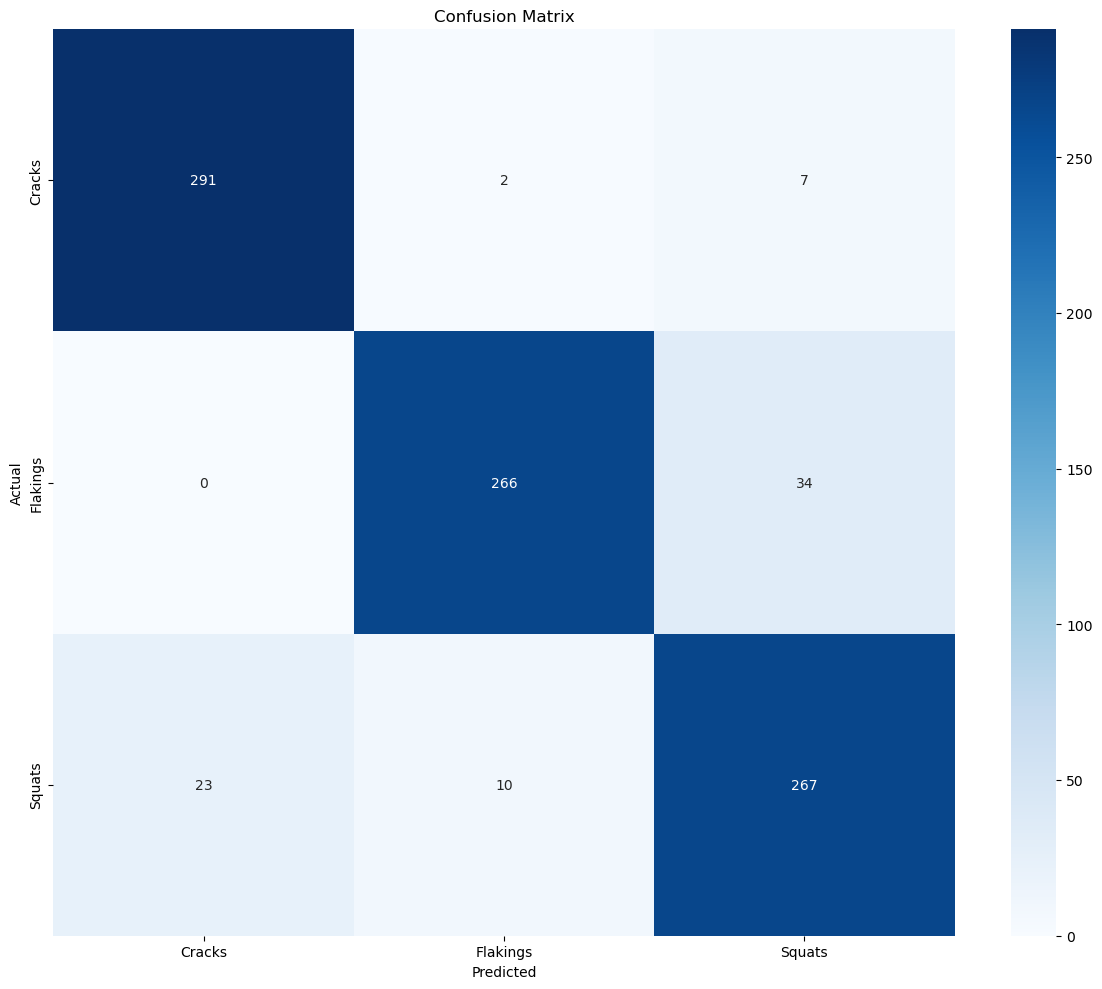

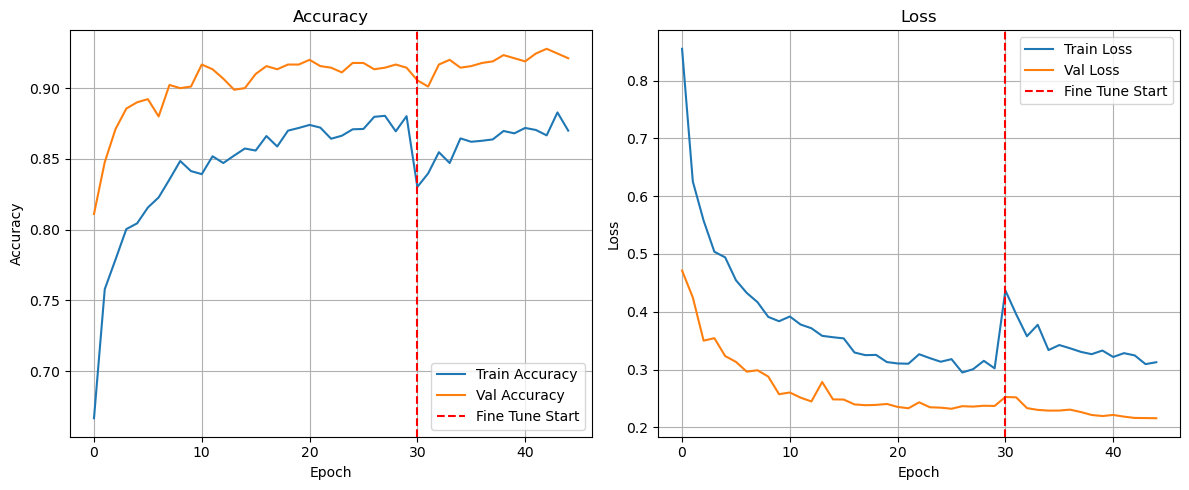

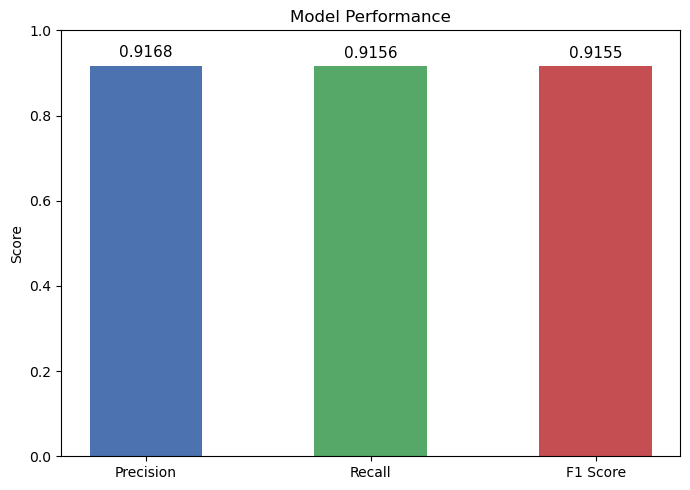


       Training Completed Successfully    
Model Saved       : railway_track_detection_final.h5
Test Accuracy     : 91.56%
F1 Score          : 0.9155
Precision         : 0.9168
Recall            : 0.9156
Confusion Matrix  : confusion_matrix.png
Accuracy/Loss     : accuracy_loss_graph.png
Performance Chart : performance.png
Report            : classification_report.txt


In [5]:
import os
import shutil
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, confusion_matrix

# ============================================
# GPU Memory Growth
# ============================================

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except:
        pass

# ============================================
# Config  ← only change this path
# ============================================

SRC_DIR  = r"C:\Users\patta\Videos\Railway Track Surface Faults Dataset\Railway Track Surface Faults Dataset"
DATA_DIR = r"C:\Users\patta\Videos\Railway Track Surface Faults Dataset\split"

IMAGE_SIZE = (380, 380)
BATCH_SIZE = 16
EPOCHS     = 30

# ============================================
# Auto Split Dataset (runs only once)
# ============================================

if not os.path.exists(DATA_DIR):
    print("Splitting dataset into train / valid / test ...")

    classes = [c for c in os.listdir(SRC_DIR) if os.path.isdir(os.path.join(SRC_DIR, c))]
    print("Classes found:", classes)

    for split in ["train", "valid", "test"]:
        for cls in classes:
            os.makedirs(os.path.join(DATA_DIR, split, cls), exist_ok=True)

    random.seed(42)

    for cls in classes:
        images = os.listdir(os.path.join(SRC_DIR, cls))
        images = [f for f in images if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        random.shuffle(images)

        n          = len(images)
        train_end  = int(n * 0.70)
        valid_end  = int(n * 0.85)

        splits = {
            "train": images[:train_end],
            "valid": images[train_end:valid_end],
            "test" : images[valid_end:]
        }

        for split, files in splits.items():
            for f in files:
                shutil.copy(
                    os.path.join(SRC_DIR, cls, f),
                    os.path.join(DATA_DIR, split, cls, f)
                )

        print(f"{cls} -> Train: {len(splits['train'])} | Valid: {len(splits['valid'])} | Test: {len(splits['test'])}")

    print("Dataset Split Done!\n")
else:
    print("Split already exists, skipping...\n")

TRAIN_DIR = os.path.join(DATA_DIR, "train")
VALID_DIR = os.path.join(DATA_DIR, "valid")
TEST_DIR  = os.path.join(DATA_DIR, "test")

# ============================================
# Data Augmentation
# ============================================

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.25,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.20,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen  = ImageDataGenerator(preprocessing_function=preprocess_input)

# ============================================
# Load Dataset
# ============================================

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode="categorical"
)

valid_generator = valid_datagen.flow_from_directory(
    VALID_DIR, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False
)

print("Class Indices:", train_generator.class_indices)

NUM_CLASSES = len(train_generator.class_indices)

# ============================================
# EfficientNetB4 (upgraded from B3)
# ============================================

base_model = EfficientNetB4(
    include_top=False,
    weights="imagenet",
    input_shape=(380, 380, 3)
)

base_model.trainable = False

# ============================================
# Custom Head
# ============================================

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

# ============================================
# Compile
# ============================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ============================================
# Callbacks
# ============================================

checkpoint = ModelCheckpoint(
    "best_model.h5", monitor="val_accuracy", save_best_only=True, verbose=1
)
early_stop = EarlyStopping(
    monitor="val_loss", patience=7, restore_best_weights=True, verbose=1
)
reduce_lr  = ReduceLROnPlateau(
    monitor="val_loss", factor=0.2, patience=3, verbose=1, min_lr=1e-7
)

# ============================================
# Phase 1 — Train Head Only
# ============================================

print("\n========== Phase 1: Training Head ==========\n")

history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

# ============================================
# Phase 2 — Fine Tune Top Layers
# ============================================

print("\n========== Phase 2: Fine Tuning ==========\n")

base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=15,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

# ============================================
# Save Final Model
# ============================================

model.save("railway_track_detection_final.h5")
print("\nModel Saved: railway_track_detection_final.h5")

# ============================================
# Test Evaluation
# ============================================

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"\nTest Accuracy : {test_accuracy * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

# ============================================
# Predictions
# ============================================

test_generator.reset()
pred              = model.predict(test_generator)
predicted_classes = np.argmax(pred, axis=1)
true_classes      = test_generator.classes
class_names       = list(test_generator.class_indices.keys())

# ============================================
# Classification Report
# ============================================

report = classification_report(true_classes, predicted_classes, target_names=class_names)
print("\nClassification Report:\n")
print(report)

with open("classification_report.txt", "w") as f:
    f.write(report)

# ============================================
# Metrics
# ============================================

f1        = f1_score(true_classes, predicted_classes, average="weighted")
precision = precision_score(true_classes, predicted_classes, average="weighted")
recall    = recall_score(true_classes, predicted_classes, average="weighted")

print(f"Weighted F1 Score : {f1:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")

# ============================================
# Confusion Matrix
# ============================================

cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

# ============================================
# Accuracy Graph (Phase 1 + Phase 2 combined)
# ============================================

acc      = history.history['accuracy']      + history_fine.history['accuracy']
val_acc  = history.history['val_accuracy']  + history_fine.history['val_accuracy']
loss     = history.history['loss']          + history_fine.history['loss']
val_loss = history.history['val_loss']      + history_fine.history['val_loss']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(acc,     label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.axvline(x=len(history.history['accuracy']), color='r', linestyle='--', label='Fine Tune Start')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(loss,     label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.axvline(x=len(history.history['loss']), color='r', linestyle='--', label='Fine Tune Start')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("accuracy_loss_graph.png")
plt.show()

# ============================================
# Performance Bar Chart
# ============================================

plt.figure(figsize=(7, 5))
bars = plt.bar(["Precision", "Recall", "F1 Score"], [precision, recall, f1],
               color=["#4C72B0", "#55A868", "#C44E52"], width=0.5)
plt.ylim(0, 1)
plt.title("Model Performance")
plt.ylabel("Score")
for bar, val in zip(bars, [precision, recall, f1]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{val:.4f}", ha='center', fontsize=11)
plt.tight_layout()
plt.savefig("performance.png")
plt.show()

# ============================================
# Final Summary
# ============================================

print("\n=========================================")
print("       Training Completed Successfully    ")
print("=========================================")
print(f"Model Saved       : railway_track_detection_final.h5")
print(f"Test Accuracy     : {test_accuracy * 100:.2f}%")
print(f"F1 Score          : {round(f1, 4)}")
print(f"Precision         : {round(precision, 4)}")
print(f"Recall            : {round(recall, 4)}")
print("Confusion Matrix  : confusion_matrix.png")
print("Accuracy/Loss     : accuracy_loss_graph.png")
print("Performance Chart : performance.png")
print("Report            : classification_report.txt")
print("=========================================")

In [ ]:
pip install --upgrade numpy tensorflow keras

In [2]:
pip install "numpy<2"

  Using cached numpy-1.26.4.tar.gz (15.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  Preparing metadata (pyproject.toml) did not run successfully.
  exit code: 1
  
  [19 lines of output]
  + C:\anaconda\python.exe C:\Users\patta\AppData\Local\Temp\pip-install-8xy87dzx\numpy_8d2ab90f1f9a476ca30489ab92a718e0\vendored-meson\meson\meson.py setup C:\Users\patta\AppData\Local\Temp\pip-install-8xy87dzx\numpy_8d2ab90f1f9a476ca30489ab92a718e0 C:\Users\patta\AppData\Local\Temp\pip-install-8xy87dzx\numpy_8d2ab90f1f9a476ca30489ab92a718e0\.mesonpy-rkwkmrja -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\patta\AppData\Local\Temp\pip-install-8xy87dzx\numpy_8d2ab90f1f9a476ca30489ab92a718e0\.mesonpy-rkwkmrja\meson-python-native-file.ini
  The Meson build system
  Version: 1.2.99
  Source dir: C:\Users\patta\AppData\Local\Temp\pip-install-8xy87dzx\numpy_8d2ab90f1f9a476ca30489ab92a718e0
  Build dir: C:\Users\patta\AppData\Local\Temp\pip-install-8xy87dzx\numpy_8d2ab90f1f9a476ca30489ab92a718e0\.mesonpy-rkwkmrja
  Bui

In [1]:
import tensorflow as tf

# Load your existing model
model = tf.keras.models.load_model("railway_track_detection_final.h5")

# Convert to TFLite with optimization (this shrinks the size)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

# Save the new, smaller file
with open("railway_track_detection_final.tflite", "wb") as f:
    f.write(tflite_model)

print("Done!")

C:\anaconda\Lib\site-packages\tensorflow\python\keras\engine\training_arrays_v1.py:37: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.0)
  from scipy.sparse import issparse  # pylint: disable=g-import-not-at-top


INFO:tensorflow:Assets written to: C:\Users\patta\AppData\Local\Temp\tmpnoo730xb\assets


INFO:tensorflow:Assets written to: C:\Users\patta\AppData\Local\Temp\tmpnoo730xb\assets


Saved artifact at 'C:\Users\patta\AppData\Local\Temp\tmpnoo730xb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 380, 380, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2090551871824: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2090551871632: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2090352602256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2090352603024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2090352602832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2090352603792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2090352603216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2090352601488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2090352602064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2090352603600: TensorSpec(shape=(), dtype=tf.resource, n

In [2]:
import os
size_mb = os.path.getsize("railway_track_detection_final.tflite") / (1024 * 1024)
print(f"New size: {size_mb:.2f} MB")

New size: 19.19 MB


In [1]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)  # must print 2.15.0 — if not, stop and recheck step 2

model = tf.keras.models.load_model("railway_track_detection_final.h5")

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open("railway_track_detection_final.tflite", "wb") as f:
    f.write(tflite_model)

import os
print(f"Saved: {os.path.getsize('railway_track_detection_final.tflite') / (1024*1024):.2f} MB")

C:\anaconda\Lib\site-packages\tensorflow\python\keras\engine\training_arrays_v1.py:37: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.0)
  from scipy.sparse import issparse  # pylint: disable=g-import-not-at-top


TensorFlow version: 2.21.0


INFO:tensorflow:Assets written to: C:\Users\patta\AppData\Local\Temp\tmp9k4p_3t8\assets


INFO:tensorflow:Assets written to: C:\Users\patta\AppData\Local\Temp\tmp9k4p_3t8\assets


Saved artifact at 'C:\Users\patta\AppData\Local\Temp\tmp9k4p_3t8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 380, 380, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1465632115024: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  1465632114832: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  1465432730768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1465432731536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1465432731344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1465432732304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1465432731728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1465432730000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1465432730576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1465432732112: TensorSpec(shape=(), dtype=tf.resource, n

In [1]:
import tensorflow as tf
print(tf.__version__)

C:\anaconda\Lib\site-packages\tensorflow\python\keras\engine\training_arrays_v1.py:37: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.0)
  from scipy.sparse import issparse  # pylint: disable=g-import-not-at-top


2.21.0
